In [ ]:
==# --- Imports ---
import os
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import csv
import matplotlib.pyplot as plt

# --- Constants ---
NUM_DRONES = 10
NUM_ROUNDS = 10
LOCAL_EPOCHS = 5
BATCH_SIZE = 32
BANDWIDTH_MBPS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(42)
torch.manual_seed(42)

# --- Step 1: Dataset Setup ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset_path = "./data/rsscn7/RSSCN7-master"
full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

test_size = 500
train_size = len(full_dataset) - test_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_indices = list(range(len(train_dataset)))
random.shuffle(train_indices)
split_size = len(train_indices) // NUM_DRONES
splits = [train_indices[i * split_size:(i + 1) * split_size] for i in range(NUM_DRONES)]

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# --- Step 2: Model Definition ---
def create_model():
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)
    for param in model.features.parameters():
        param.requires_grad = True  # Fine-tune all layers
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)
    return model.to(DEVICE)


In [ ]:
# Fed Avg
def fedavg(state_list):
    avg_state = {}
    for key in state_list[0].keys():
        avg_state[key] = sum([state[key] for state in state_list]) / len(state_list)
    return avg_state

In [ ]:
# --- Step 3: Router and VM ---
class Router:
    def __init__(self, threshold=0.10):  # Reduced threshold for filtering
        self.threshold = threshold

    def inspect(self, image_tensor):
        return "yes" if image_tensor.mean().item() > self.threshold else "no"

class VM:
    def __init__(self):
        self.model = create_model()

    def process(self, image, label):
        self.model.eval()
        with torch.no_grad():
            image = image.unsqueeze(0).to(DEVICE)
            output = self.model(image)
            _, pred = torch.max(output, 1)
        return pred.item(), label

# --- Step 4: Drone Class ---
class Drone:
    def __init__(self, drone_id, indices):
        self.id = drone_id
        self.dataset = Subset(full_dataset, indices)
        self.loader = DataLoader(self.dataset, batch_size=BATCH_SIZE, shuffle=True)
        self.model = create_model()
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.images_used = 0
        print(f"Drone {drone_id+1} initialized.")

    def local_train(self, epochs):
        router = Router()
        vm = VM()
        self.model.train()
        total_loss, steps = 0, 0
        used_images = 0

        for _ in range(epochs):
            for data, targets in self.loader:
                for i in range(len(data)):
                    image = data[i]
                    label = targets[i]
                    if router.inspect(image) == "yes":
                        pred, lbl = vm.process(image, label)
                        image = image.unsqueeze(0).to(DEVICE)
                        label = torch.tensor([label]).to(DEVICE)
                        self.optimizer.zero_grad()
                        output = self.model(image)
                        loss = self.criterion(output, label)
                        loss.backward()
                        self.optimizer.step()
                        total_loss += loss.item()
                        steps += 1
                        used_images += 1

        self.images_used = used_images
        return total_loss / steps if steps else 0

    def get_state(self):
        return {k: v.cpu().clone() for k, v in self.model.state_dict().items()}

    def set_state(self, state):
        self.model.load_state_dict(state)

    def evaluate(self):
        self.model.eval()
        correct = total = 0
        with torch.no_grad():
            for data, targets in test_loader:
                data, targets = data.to(DEVICE), targets.to(DEVICE)
                outputs = self.model(data)
                _, pred = torch.max(outputs, 1)
                correct += (pred == targets).sum().item()
                total += targets.size(0)
        return 100.0 * correct / total

# --- Step 5: Cloud ---
class Cloud:
    def __init__(self):
        self.model_state = None

    def receive_model(self, state):
        size_mb = sum(p.numel() * 4 for p in state.values()) / 1e6
        latency = (size_mb / BANDWIDTH_MBPS) * np.random.normal(1.0, 0.05)
        print(f" Cloud: Received model ({size_mb:.2f} MB, {latency * 1000:.2f} ms latency)")
        time.sleep(latency)
        self.model_state = state.copy()
        return latency

    def distribute_model(self):
        return self.model_state.copy()

    def set_model(self, state):
        self.model_state = state.copy()


In [ ]:
class FogBroker:
    def __init__(self, threshold_mb=16.5):
        self.threshold_mb = threshold_mb
        self.accepted_rounds = []
        self.total_models = []
        self.fitness_scores = []

    def filter_models(self, drone_states, drone_ids, drone_delays, drone_accuracies):
        valid, reprocess, drop = [], [], []
        valid_ids, reprocess_ids, drop_ids = [], [], []

        print("\n FogBroker Filtering:")
        fitness_scores_this_round = []

        for i, (state, delay, acc) in enumerate(zip(drone_states, drone_delays, drone_accuracies)):
            drone_id = drone_ids[i]
            size_mb = sum(p.numel() * 4 for p in state.values()) / 1e6 * np.random.uniform(0.95, 1.05)
            self.total_models.append(1)

            if size_mb <= self.threshold_mb:
                valid.append({
                    "drone_id": drone_id,
                    "state": state,
                    "accuracy": acc,
                    "total_delay": delay
                })
                valid_ids.append(drone_id)
                fitness = (1 - acc / 100) + 0.05 * (delay / 1.0)  # Adjusted delay normalization
                fitness_scores_this_round.append(fitness)

                print(f" Drone {drone_id+1} → VALID | Size: {size_mb:.2f} MB | Acc: {acc:.2f}% | Delay: {delay*1000:.2f} ms")

            elif size_mb <= self.threshold_mb * 1.2:
                reprocess.append(state)
                reprocess_ids.append(drone_id)
                print(f" Drone {drone_id+1} → REPROCESS | Size: {size_mb:.2f} MB")

            else:
                drop.append(state)
                drop_ids.append(drone_id)
                print(f" Drone {drone_id+1} → DROPPED | Size: {size_mb:.2f} MB")

        self.accepted_rounds.append(len(valid))
        self.fitness_scores.append(fitness_scores_this_round)

        return valid, reprocess, drop, valid_ids, reprocess_ids, drop_ids
    def get_acceptance_rate(self):
        if not self.total_models:
            return 0
        return self.accepted_rounds[-1] / self.total_models[-1]

    def get_average_fitness(self):
        if not self.fitness_scores or not self.fitness_scores[-1]:
            return 0
        return sum(self.fitness_scores[-1]) / len(self.fitness_scores[-1])


In [ ]:
def abc_select_models(model_infos, alpha=1.0, beta=0.05, num_selected=3, max_iter=5):
    if len(model_infos) <= num_selected:
        return model_infos

    max_delay = max([info['total_delay'] for info in model_infos])

    def fitness_fn(info):
        return alpha * (1 - info['accuracy']) + beta * (info['total_delay'] / max_delay)

    population = model_infos[:]
    best_solution = min(population, key=fitness_fn)

    for _ in range(max_iter):
        new_population = []
        for info in population:
            partner = random.choice(population)
            if fitness_fn(partner) < fitness_fn(info):
                new_population.append(partner)
            else:
                new_population.append(info)
        population = new_population
        candidate_best = min(population, key=fitness_fn)
        if fitness_fn(candidate_best) < fitness_fn(best_solution):
            best_solution = candidate_best

    sorted_by_fitness = sorted(population, key=fitness_fn)
    return sorted_by_fitness[:num_selected]


In [ ]:
# --- Step 7: Federated Training Loop using ABC ---

# --- System Cost Coefficients ---
CPU_RATE = 0.5        # Cost per second of CPU usage
MEMORY_RATE = 0.1     # Cost per MB of memory usage
BANDWIDTH_RATE = 0.05 # Cost per MB of bandwidth usage

drones = [Drone(i, splits[i]) for i in range(NUM_DRONES)]
cloud = Cloud()
logs = []
global_accs = []

routerA_ids = list(range(5))
routerB_ids = list(range(5, 10))

alpha = 1.0
beta = 0.05

for rnd in range(1, NUM_ROUNDS + 1):
    print(f"\n================ Round {rnd} ================\n")
    local_states = [None] * NUM_DRONES
    losses = [None] * NUM_DRONES
    round_latency = 0.0
    model_infos = []

    for i, drone in enumerate(drones):
        print(f"Drone {i+1} training...")
        loss = drone.local_train(LOCAL_EPOCHS)
        state = drone.get_state()
        exec_time = np.random.uniform(0.4, 0.6)  # Simulated training delay
        model_size_mb = sum(p.numel() * 4 for p in state.values()) / 1e6 * np.random.uniform(0.95, 1.05)
        transmission_delay = (model_size_mb / BANDWIDTH_MBPS) * np.random.normal(1.0, 0.05)
        total_delay = exec_time + transmission_delay
        round_latency += total_delay
        acc = drone.evaluate()

        cost = (CPU_RATE * exec_time) + (MEMORY_RATE * model_size_mb) + (BANDWIDTH_RATE * model_size_mb)

        local_states[i] = state
        losses[i] = loss

        model_infos.append({
            "drone_id": i,
            "state": state,
            "accuracy": acc,
            "total_delay": total_delay,
            "cost": cost
        })

        print(f"  Loss: {loss:.4f}, Accuracy: {acc:.2f}%, Delay: {total_delay * 1000:.2f} ms")

    # --- Fog Filtering ---
    fogA = FogBroker()
    fogB = FogBroker()

    valid_A, _, _, valid_ids_A, _, _ = fogA.filter_models(
        [local_states[i] for i in routerA_ids], routerA_ids,
        [model_infos[i]["total_delay"] for i in routerA_ids],
        [model_infos[i]["accuracy"] / 100 for i in routerA_ids]
    )
    valid_B, _, _, valid_ids_B, _, _ = fogB.filter_models(
        [local_states[i] for i in routerB_ids], routerB_ids,
        [model_infos[i]["total_delay"] for i in routerB_ids],
        [model_infos[i]["accuracy"] / 100 for i in routerB_ids]
    )

    model_infos_A = [model_infos[i] for i in valid_ids_A]
    model_infos_B = [model_infos[i] for i in valid_ids_B]

    # --- ABC Model Selection ---
    print("\n ABC Selecting Top 3 Models from Router A")
    top_A = abc_select_models(model_infos_A, alpha, beta)
    print(" Selected drones from Router A:", [info['drone_id'] + 1 for info in top_A])
    agg_A = fedavg([info["state"] for info in top_A]) if top_A else None

    print("\n ABC Selecting Top 3 Models from Router B")
    top_B = abc_select_models(model_infos_B, alpha, beta)
    print(" Selected drones from Router B:", [info['drone_id'] + 1 for info in top_B])
    agg_B = fedavg([info["state"] for info in top_B]) if top_B else None

    # --- Cloud Aggregation ---
    if agg_A and agg_B:
        print("\n  Cloud Aggregating filtered updates...")
        agg_cloud = fedavg([agg_A, agg_B])
        cloud_latency = cloud.receive_model(agg_cloud)
        round_latency += cloud_latency

        cloud.set_model(agg_cloud)
        updated_state = cloud.distribute_model()

        for drone in drones:
            drone.set_state(updated_state)

        # Global model accuracy
        acc = drones[4].evaluate()
        global_accs.append(acc)
        print(f"  Fog Head Accuracy (Drone 5): {acc:.2f}%")

        # Average Cost, Acceptance Rate, and Fitness
        avg_cost = np.mean([info["cost"] for info in model_infos])
        acc_rate_A = fogA.get_acceptance_rate()
        acc_rate_B = fogB.get_acceptance_rate()
        avg_fit_A = fogA.get_average_fitness()
        avg_fit_B = fogB.get_average_fitness()

        logs.append([
            rnd, acc, round_latency * 1000, cloud_latency * 1000,
            avg_cost, acc_rate_A, acc_rate_B, avg_fit_A, avg_fit_B
        ] + losses)

    else:
        print("  Aggregation failed due to no valid models.")


Drone 1 initialized.
Drone 2 initialized.
Drone 3 initialized.
Drone 4 initialized.
Drone 5 initialized.
Drone 6 initialized.
Drone 7 initialized.
Drone 8 initialized.
Drone 9 initialized.
Drone 10 initialized.

================ Round 1 ================

Drone 1 training...
  Loss: 0.9877, Accuracy: 19.80%, Delay: 851.44 ms
Drone 2 training...
  Loss: 1.0007, Accuracy: 10.00%, Delay: 735.69 ms
Drone 3 training...
  Loss: 0.7666, Accuracy: 9.60%, Delay: 821.79 ms
Drone 4 training...
  Loss: 1.0829, Accuracy: 21.00%, Delay: 815.21 ms
Drone 5 training...
  Loss: 1.0215, Accuracy: 21.20%, Delay: 910.18 ms
Drone 6 training...
  Loss: 1.0840, Accuracy: 18.60%, Delay: 793.59 ms
Drone 7 training...
  Loss: 0.8038, Accuracy: 14.00%, Delay: 819.65 ms
Drone 8 training...
  Loss: 1.0722, Accuracy: 7.60%, Delay: 887.48 ms
Drone 9 training...
  Loss: 0.8448, Accuracy: 14.80%, Delay: 817.28 ms
Drone 10 training...
  Loss: 0.8697, Accuracy: 21.00%, Delay: 783.67 ms

 FogBroker Filtering:
 Drone 1 → VA

In [ ]:
# --- Step 8: Save Logs to CSV ---
csv_path = "./fed_logs_abc_optimizer.csv"

with open(csv_path, "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Round", "Global Accuracy (%)", "Total Latency (ms)", "Cloud Latency (ms)" ,"Average Cost", "Acceptance A", "Acceptance B", "Fitness A", "Fitness B"] +
                    [f"Drone {i+1} Loss" for i in range(NUM_DRONES)])
    writer.writerows(logs)

print(f" Logs saved to: {csv_path}")


 Logs saved to: ./fed_logs_abc_optimizer.csv


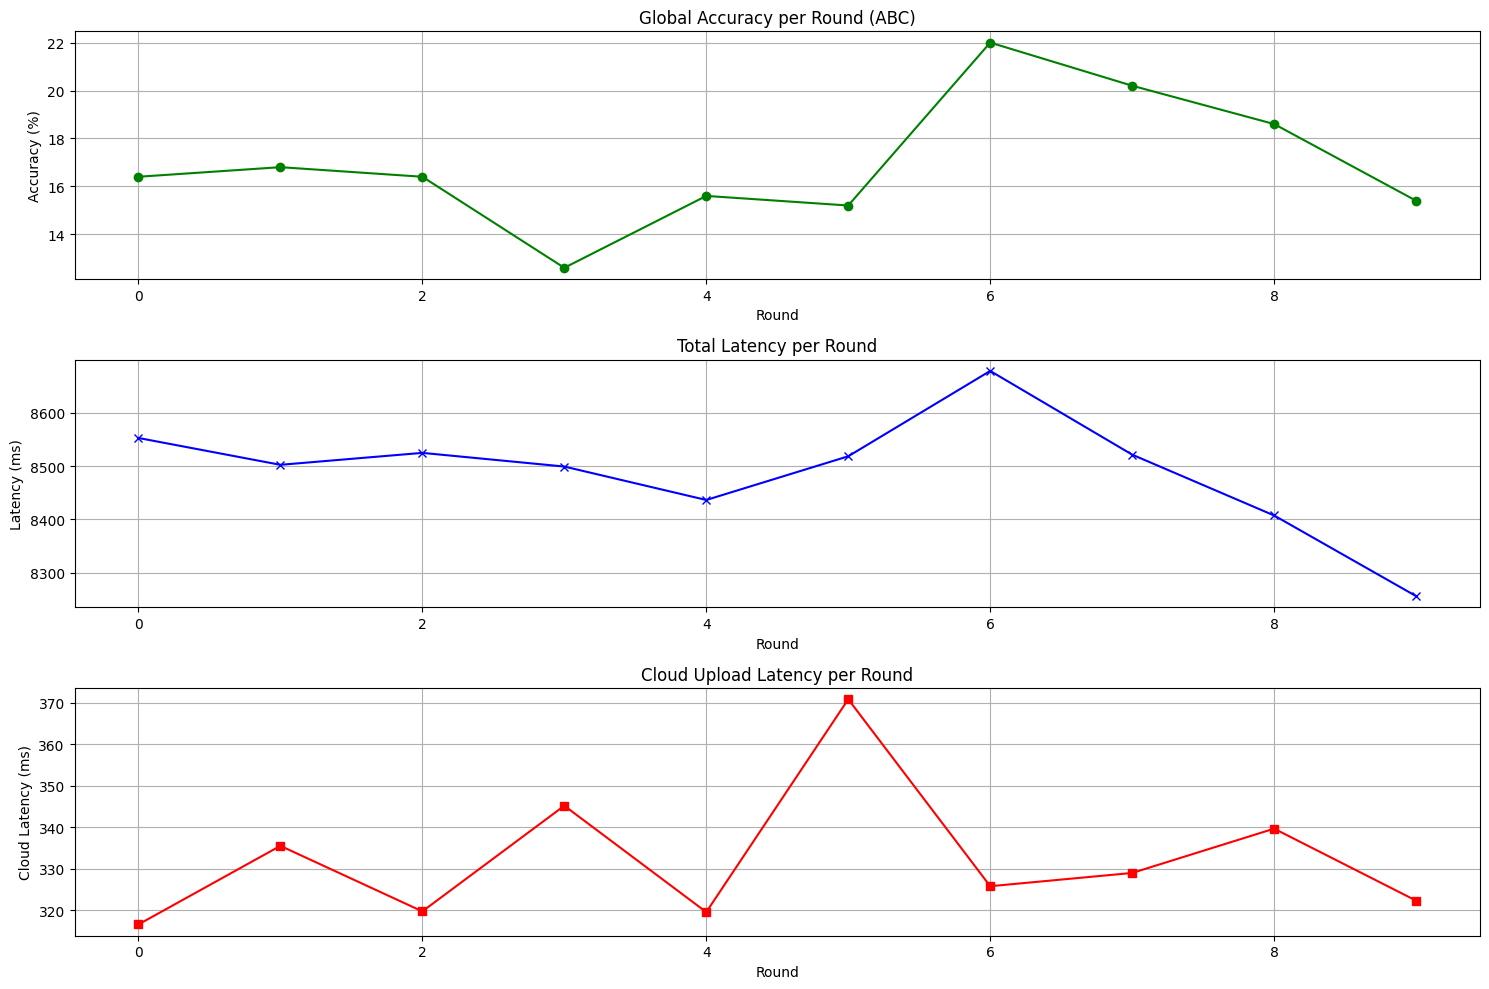

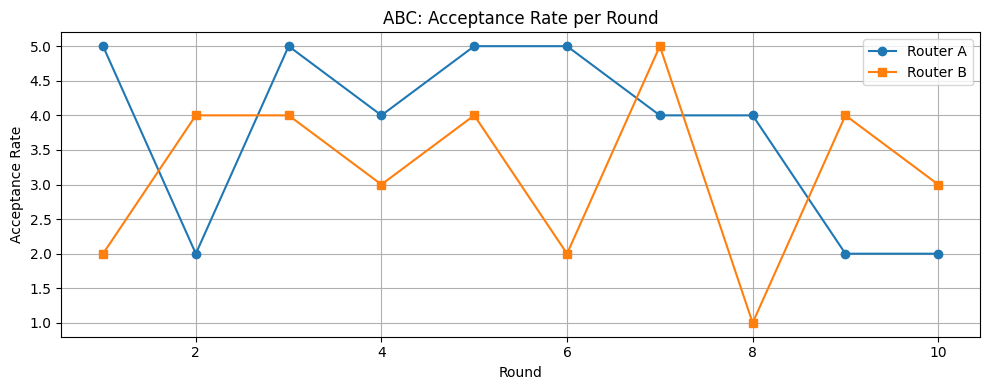

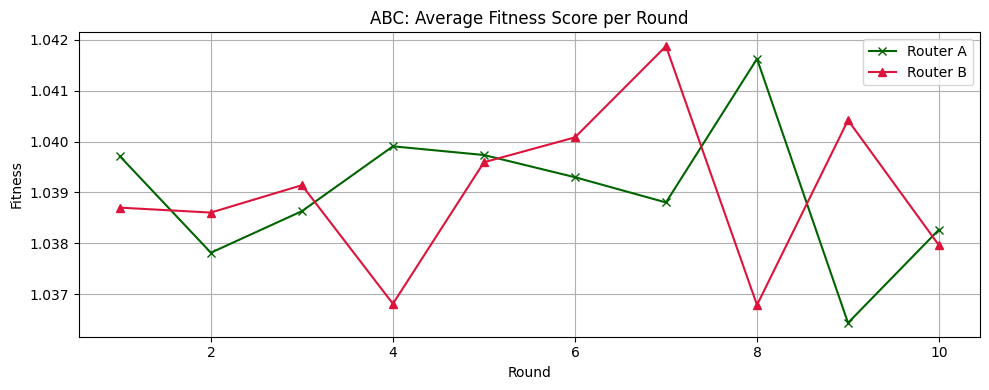

In [ ]:
# --- Step 9: Plot Metrics ---
plt.figure(figsize=(15, 10))

# Accuracy per round
plt.subplot(3, 1, 1)
plt.plot(global_accs, marker='o', color='green')
plt.title("Global Accuracy per Round (ABC)")
plt.xlabel("Round")
plt.ylabel("Accuracy (%)")
plt.grid(True)

# Total Latency
total_latency_ms = [row[2] for row in logs]
plt.subplot(3, 1, 2)
plt.plot(total_latency_ms, marker='x', color='blue')
plt.title("Total Latency per Round")
plt.xlabel("Round")
plt.ylabel("Latency (ms)")
plt.grid(True)

# Cloud Latency
cloud_latency_ms = [row[3] for row in logs]
plt.subplot(3, 1, 3)
plt.plot(cloud_latency_ms, marker='s', color='red')
plt.title("Cloud Upload Latency per Round")
plt.xlabel("Round")
plt.ylabel("Cloud Latency (ms)")
plt.grid(True)

plt.tight_layout()
plt.show()

rounds = list(range(1, NUM_ROUNDS + 1))

# Acceptance Rate (A & B)
accept_A = [row[5] for row in logs]
accept_B = [row[6] for row in logs]
plt.figure(figsize=(10, 4))
plt.plot(rounds, accept_A, marker='o', label='Router A')
plt.plot(rounds, accept_B, marker='s', label='Router B')
plt.title("ABC: Acceptance Rate per Round")
plt.xlabel("Round")
plt.ylabel("Acceptance Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Fitness Score (A & B)
fitness_A = [row[7] for row in logs]
fitness_B = [row[8] for row in logs]
plt.figure(figsize=(10, 4))
plt.plot(rounds, fitness_A, marker='x', label='Router A', color='darkgreen')
plt.plot(rounds, fitness_B, marker='^', label='Router B', color='crimson')
plt.title("ABC: Average Fitness Score per Round")
plt.xlabel("Round")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()